# Common Libraries

In [1]:
import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import xml.etree.ElementTree as ET

# mujoco
if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# opensim
sys.path.append("/home/seojin/miniforge3/envs/myoconverter/lib/python3.10/site-packages")
import opensim

In [2]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from sj_opensim import extract_muscle_names, extract_muscle_params
from biomechanics_util import extract_mujoco_muscle_params

# Opensim

In [3]:
osim_dir_path = "/mnt/sdb2/DeepProprioception/OpenSim"
osim_file_path = os.path.join(osim_dir_path, "MOBL_ARMS_41.osim")
osim_muscle_params = extract_muscle_params(osim_file_path)

# Mujoco

In [4]:
mujoco_model_path = "/mnt/ext1/seojin/temp/MOBL_ARMS_41_bounded/temp_cvt3.xml"
mujoco_muscle_params = extract_mujoco_muscle_params(mujoco_model_path)
muscle_names = mujoco_muscle_params.columns
gainparam_names = list(mujoco_muscle_params.index)

In [5]:
osim_muscle_params.to_csv("/mnt/ext1/seojin/temp/osim_muscle_params.csv")
mujoco_muscle_params.to_csv("/mnt/ext1/seojin/temp/mujoco_muscle_params.csv")

# Myoarm

In [6]:
myoarm_model_path = "/home/seojin/biomechanics_tools/myo_sim/arm/myoarm.xml"
myoarm_muscle_params = extract_mujoco_muscle_params(myoarm_model_path)
apl_i = list(myoarm_muscle_params.columns).index("APL")
myoarm_muscle_params = myoarm_muscle_params.iloc[:, :apl_i + 1]
myoarm_muscle_params.columns = muscle_names

In [7]:
def compare_plot(param_name):
    fig, axis = plt.subplots(1)
    fig.set_figwidth(10)
    axis.plot(mujoco_muscle_params.loc[param_name], label = "converted")
    axis.plot(myoarm_muscle_params.loc[param_name], label = "myoarm")
    axis.set_xticks(np.arange(len(muscle_names)), muscle_names, rotation = 90)
    axis.set_title(param_name)
    axis.legend()

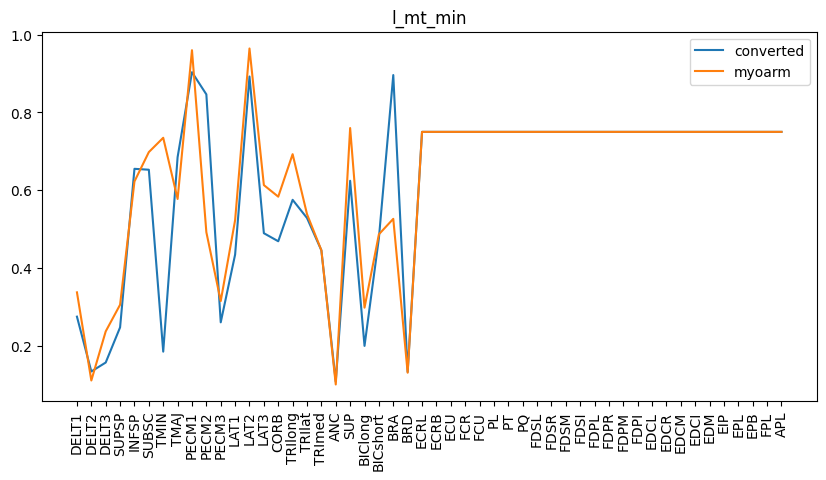

In [8]:
compare_plot("l_mt_min")

In [20]:
np.max(myoarm_muscle_params.loc["l_mt_max"])

1.6

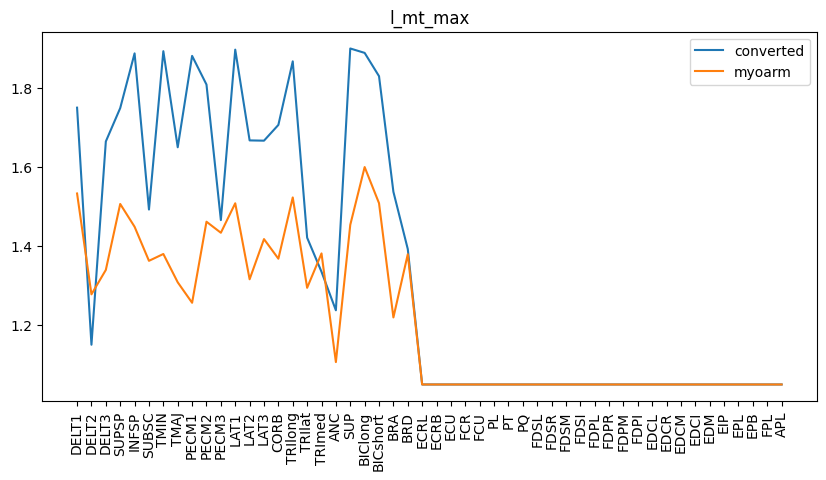

In [9]:
compare_plot("l_mt_max")

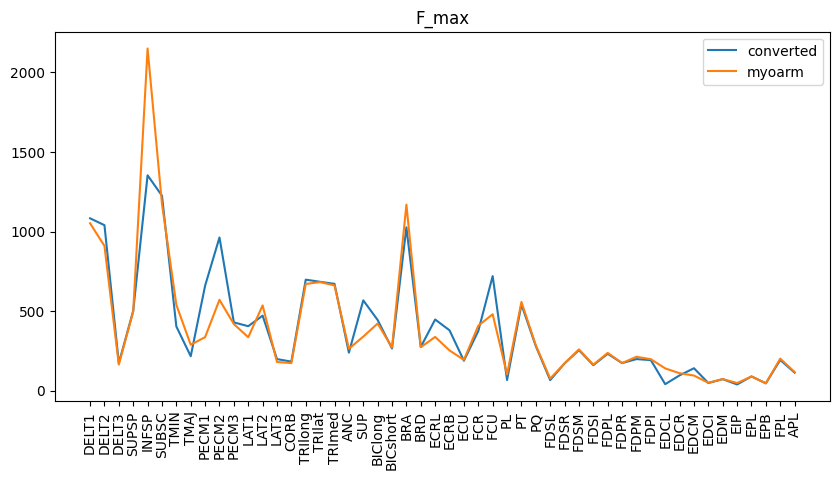

In [10]:
compare_plot("F_max")

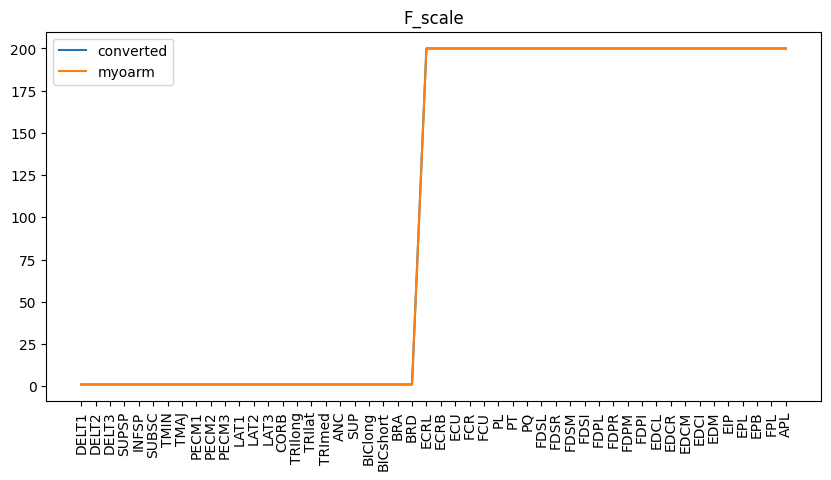

In [11]:
compare_plot("F_scale")

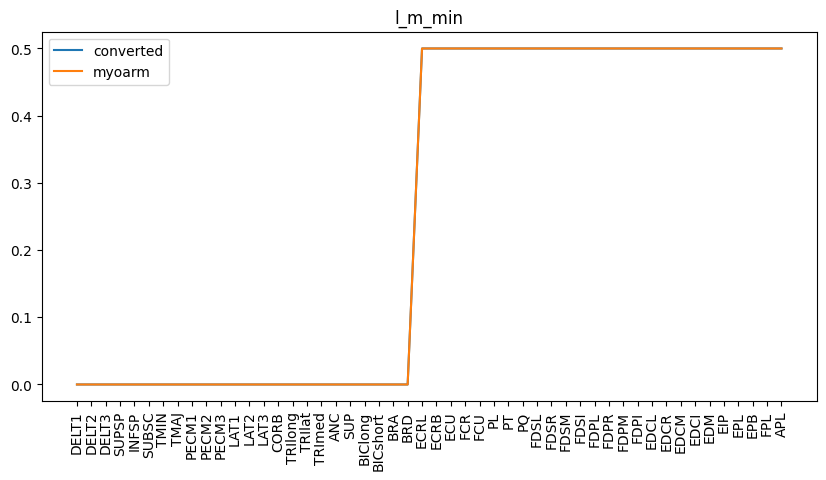

In [12]:
compare_plot("l_m_min")

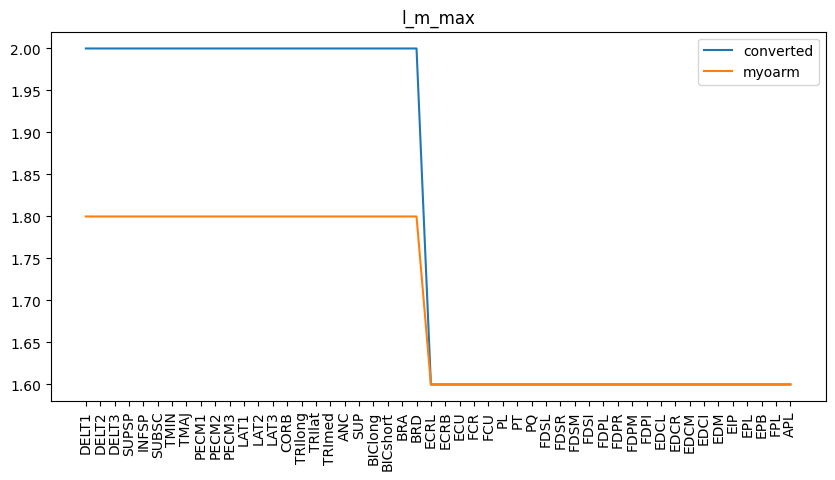

In [13]:
compare_plot("l_m_max")

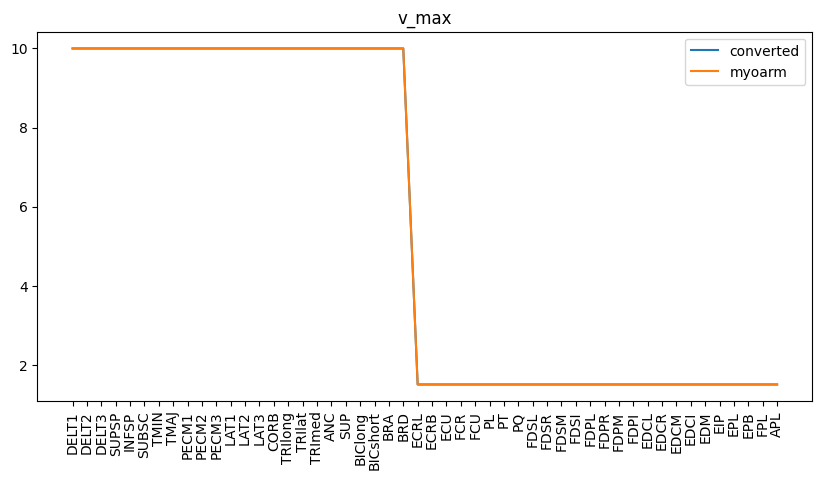

In [14]:
compare_plot("v_max")

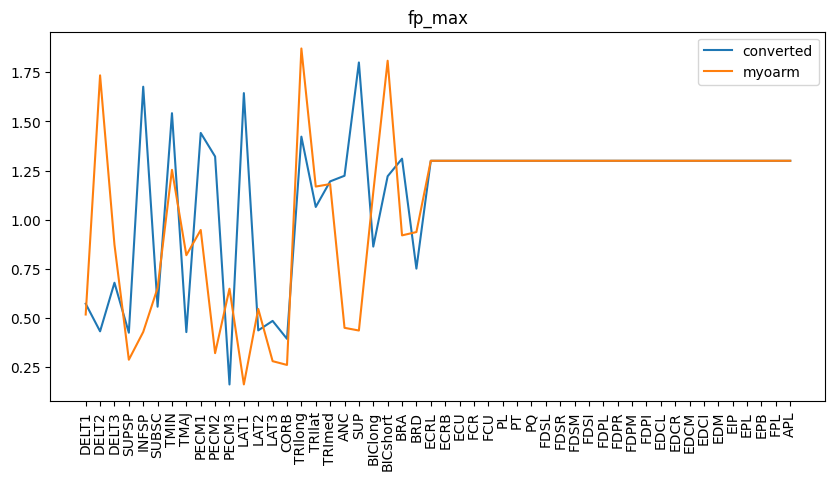

In [15]:
compare_plot("fp_max")

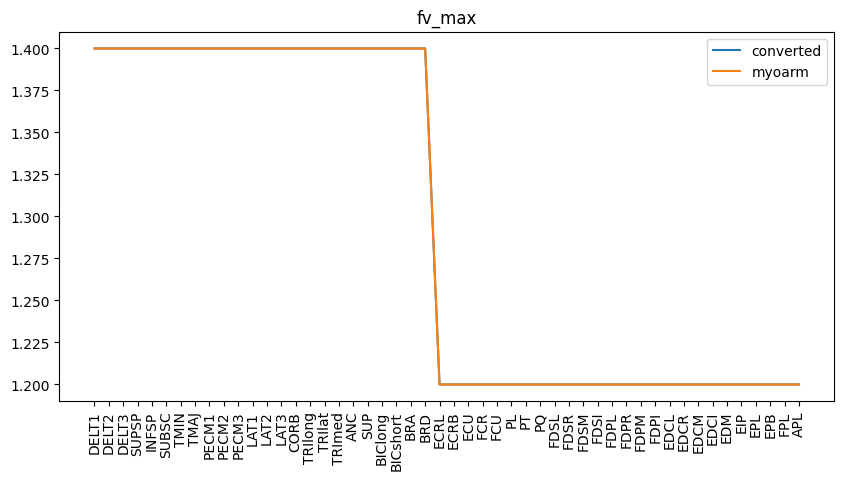

In [16]:
compare_plot("fv_max")

# Change

In [21]:
# os.system(f"cp {mujoco_model_path} {mujoco_model_path}.original")

scaled_muscles = list(myoarm_muscle_params.loc[:, list(myoarm_muscle_params.loc["F_scale"] == 200)].columns)

In [22]:
tree = ET.parse(mujoco_model_path)
root = tree.getroot()

In [31]:
l_mt_min_i = gainparam_names.index("l_mt_min")
l_mt_max_i = gainparam_names.index("l_mt_max")
f_scale_i = gainparam_names.index("F_scale")
l_m_min_i = gainparam_names.index("l_m_min")
l_m_max_i = gainparam_names.index("l_m_max")
v_max_i = gainparam_names.index("v_max")
fp_max_i = gainparam_names.index("fp_max")
fv_max_i = gainparam_names.index("fv_max")

for muscle_name in scaled_muscles:
    for actuator in root.findall(".//actuator/*"):
        if actuator.get("name") == muscle_name:
            gainprm = actuator.get("gainprm")
            gainprm_val = gainprm.split(" ")
            gainprm_val[l_mt_min_i] = str(myoarm_muscle_params.loc["l_mt_min", muscle_name])
            gainprm_val[l_mt_max_i] = str(myoarm_muscle_params.loc["l_mt_max", muscle_name])
            gainprm_val[l_m_min_i] = str(myoarm_muscle_params.loc["l_m_min", muscle_name])
            gainprm_val[l_m_max_i] = str(myoarm_muscle_params.loc["l_m_max", muscle_name])
            gainprm_val[f_scale_i] = str(myoarm_muscle_params.loc["F_scale", muscle_name])
            gainprm_val[v_max_i] = str(myoarm_muscle_params.loc["v_max", muscle_name])
            gainprm_val[fp_max_i] = str(myoarm_muscle_params.loc["fp_max", muscle_name])
            gainprm_val[fv_max_i] = str(myoarm_muscle_params.loc["fv_max", muscle_name])
            new_val = " ".join(gainprm_val)
            actuator.set("gainprm", new_val)
            
tree.write(mujoco_model_path, encoding='utf-8', xml_declaration=True)
print(f"saved: {mujoco_model_path}")